# Cardiovascular Disease Prognosis

## Objective
"Cardiovascular diseases are the leading cause of death globally. While early detection significantly improves survival rates, many individuals do not have immediate access to complete clinical blood panels."
Our objective is to develop a ML based Decision Support System that predicts a user's probability of having cardiovascular disease based on accessible metrics. Our primary motivation is to build an adaptive tool: acknowledging that a general user might know their height, weight, and age, but might not know their exact glucose or cholesterol levels. Instead of failing, our system will adapt to missing inputs, providing a baseline risk probability that updates as the user inputs more clinical data.

**Dataset:** [Cardiovascular Disease Dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset) <br>
**Problem:** Binary Classification

---

## 1. Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

## 2. Load data and cleaning

In [18]:
DATA_PATH = "docs/cardio_train.csv"
df = pd.read_csv(DATA_PATH, sep=';')  # Specify the correct delimiter
print(df.head())
print(df.shape)

# cleaning data
# remove systolic BP < 40 or > 370
# remove diastolic BP < 0 or > 250
initial_shape = df.shape
df = df[(df['ap_hi'] > 40) & (df['ap_hi'] < 370)]
df = df[(df['ap_lo'] > 0) & (df['ap_lo'] < 250)]
final_shape = df.shape
print(f"Removed {initial_shape[0] - final_shape[0]} rows. New shape: {final_shape}")
df.to_csv("docs/cardio_train_cleaned.csv", index=False)

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)
Removed 1190 rows. New shape: (68810, 13)


## 3. Train-test split

In [19]:
df_cleaned = pd.read_csv("docs/cardio_train_cleaned.csv")
y = df_cleaned['cardio']
X = df_cleaned.drop(columns=['cardio'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
for name, arr in [("y_train", y_train), ("y_test", y_test)]:
    classes, counts = np.unique(arr, return_counts=True)
    for c, n in zip(classes, counts):
        print(f"{name} — class {c}: {n} ({n/len(arr)*100:.1f}%)")

y_train — class 0: 27806 (50.5%)
y_train — class 1: 27242 (49.5%)
y_test — class 0: 6951 (50.5%)
y_test — class 1: 6811 (49.5%)


## 4. Algorithms Training and Evaluation

Baseline Classification Report:

Accuracy: 0.7307077459671559
Precision: 0.7550517496303598
Recall: 0.674790779621201
F1-Score: 0.7126686307954722


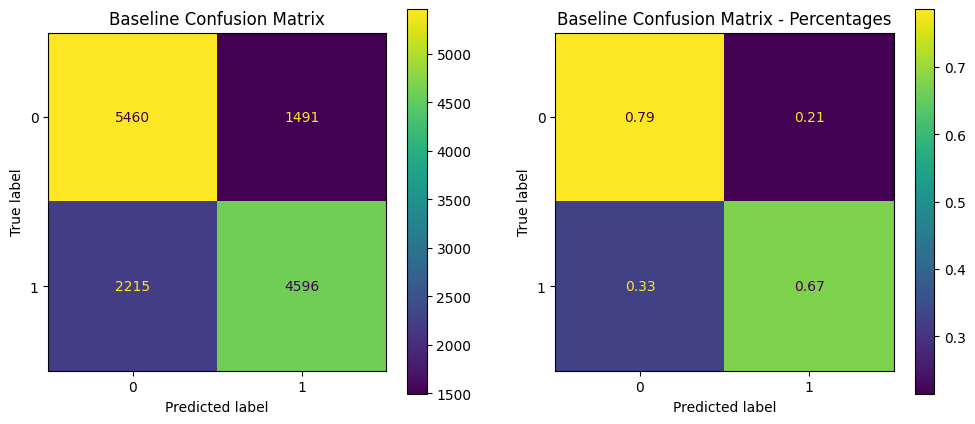

Naive Bayes Classification Report:

Accuracy: 0.7117424792908007
Precision: 0.7612049963262307
Recall: 0.6084275436793423
F1-Score: 0.676295389636883


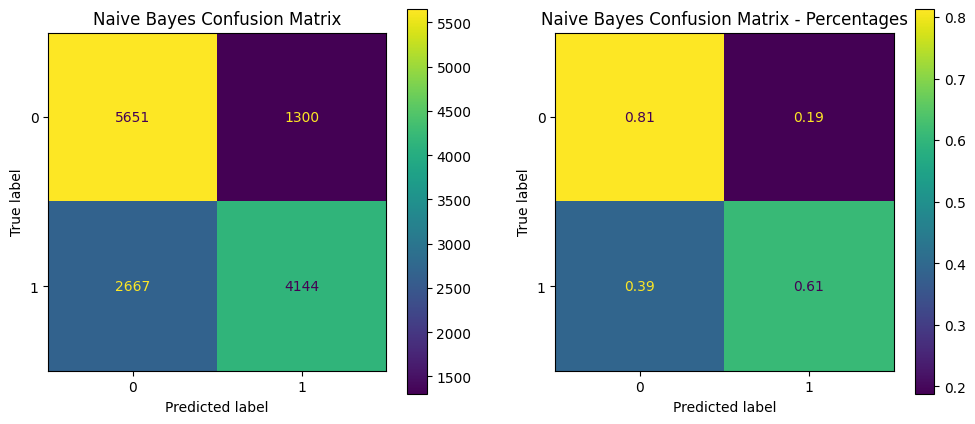

Decision Tree Classification Report:

Accuracy: 0.636971370440343
Precision: 0.634584013050571
Recall: 0.6282484216708266
F1-Score: 0.6314003246274162


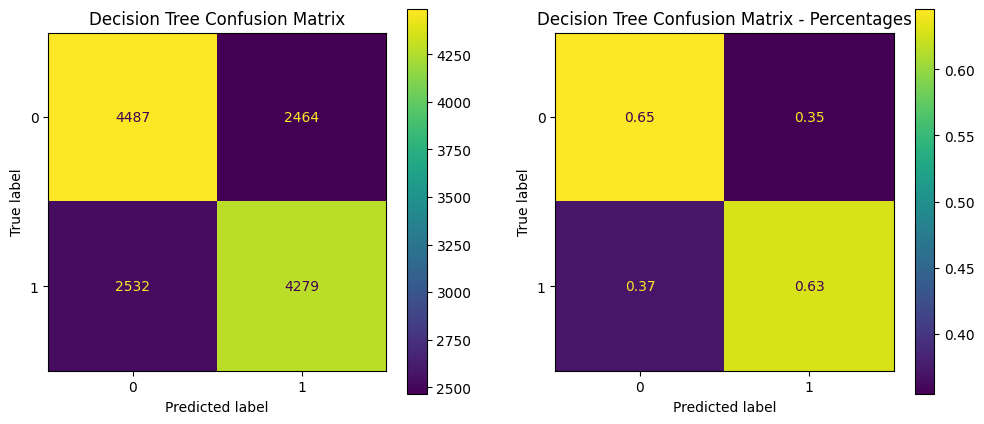

Linear SVM Classification Report:

Accuracy: 0.7293271326842029
Precision: 0.7574240907574241
Recall: 0.6665687857876964
F1-Score: 0.7090980085903944


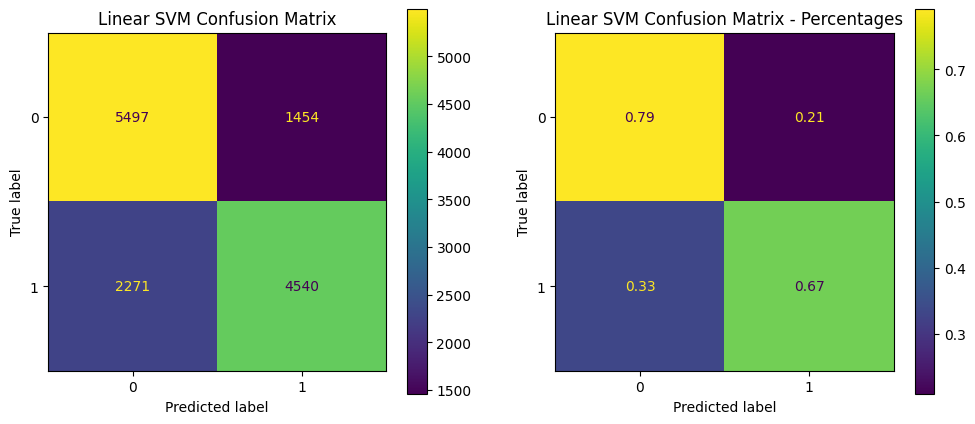

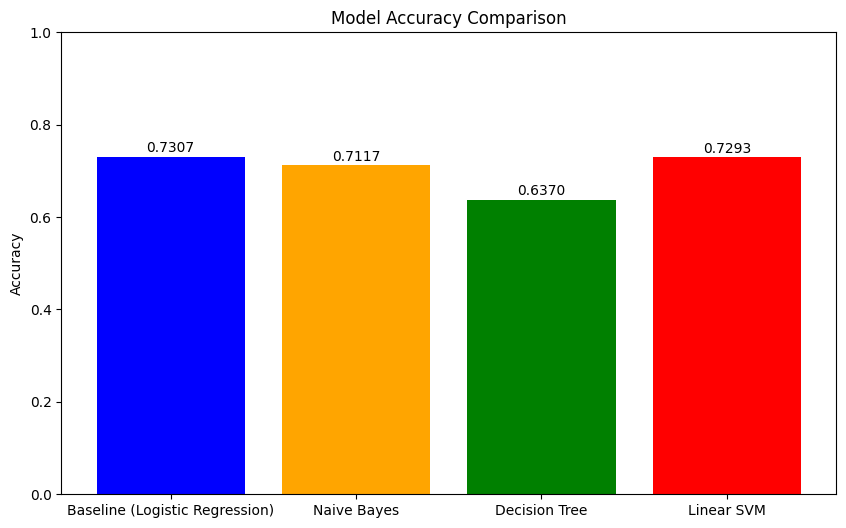

In [20]:
# logistic regression baseline
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline Classification Report:\n")
print("Accuracy:", baseline_acc)
print("Precision:", classification_report(y_test, baseline_pred, output_dict=True)["1"]["precision"])
print("Recall:", classification_report(y_test, baseline_pred, output_dict=True)["1"]["recall"])
print("F1-Score:", classification_report(y_test, baseline_pred, output_dict=True)["1"]["f1-score"])

# logistic regression confusion matrix - with and without percentage
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, baseline_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline.classes_)
disp.plot(ax=ax1)
plt.title("Baseline Confusion Matrix")
ax2 = plt.subplot(1, 2, 2)
cm_perc = confusion_matrix(y_test, baseline_pred, normalize="true")
disp_perc = ConfusionMatrixDisplay(confusion_matrix=cm_perc, display_labels=baseline.classes_)
disp_perc.plot(ax=ax2)
plt.title("Baseline Confusion Matrix - Percentages")
plt.show()

# naive bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Classification Report:\n")
print("Accuracy:", nb_acc)
print("Precision:", classification_report(y_test, nb_pred, output_dict=True)["1"]["precision"])
print("Recall:", classification_report(y_test, nb_pred, output_dict=True)["1"]["recall"])
print("F1-Score:", classification_report(y_test, nb_pred, output_dict=True)["1"]["f1-score"])

# naive bayes confusion matrix - with and without percentage
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
disp.plot(ax=ax1)
plt.title("Naive Bayes Confusion Matrix")
ax2 = plt.subplot(1, 2, 2)
cm_perc = confusion_matrix(y_test, nb_pred, normalize="true")
disp_perc = ConfusionMatrixDisplay(confusion_matrix=cm_perc, display_labels=nb.classes_)
disp_perc.plot(ax=ax2)
plt.title("Naive Bayes Confusion Matrix - Percentages")
plt.show()

# decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Classification Report:\n")
print("Accuracy:", dt_acc)
print("Precision:", classification_report(y_test, dt_pred, output_dict=True)["1"]["precision"])
print("Recall:", classification_report(y_test, dt_pred, output_dict=True)["1"]["recall"])
print("F1-Score:", classification_report(y_test, dt_pred, output_dict=True)["1"]["f1-score"])

# decision tree confusion matrix - with and without percentage
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(ax=ax1)
plt.title("Decision Tree Confusion Matrix")
ax2 = plt.subplot(1, 2, 2)
cm_perc = confusion_matrix(y_test, dt_pred, normalize="true")
disp_perc = ConfusionMatrixDisplay(confusion_matrix=cm_perc, display_labels=dt.classes_)
disp_perc.plot(ax=ax2)
plt.title("Decision Tree Confusion Matrix - Percentages")
plt.show()

# linear SVM
svm_linear = LinearSVC(max_iter=10000, random_state=42)
svm_linear.fit(X_train, y_train)
svm_linear_pred = svm_linear.predict(X_test)
svm_acc = accuracy_score(y_test, svm_linear_pred)
print("Linear SVM Classification Report:\n")
print("Accuracy:", svm_acc)
print("Precision:", classification_report(y_test, svm_linear_pred, output_dict=True)["1"]["precision"])
print("Recall:", classification_report(y_test, svm_linear_pred, output_dict=True)["1"]["recall"])
print("F1-Score:", classification_report(y_test, svm_linear_pred, output_dict=True)["1"]["f1-score"])

# linear SVM confusion matrix - with and without percentage
plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, svm_linear_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_linear.classes_)
disp.plot(ax=ax1)
plt.title("Linear SVM Confusion Matrix")
ax2 = plt.subplot(1, 2, 2)
cm_perc = confusion_matrix(y_test, svm_linear_pred, normalize="true")
disp_perc = ConfusionMatrixDisplay(confusion_matrix=cm_perc, display_labels=svm_linear.classes_)
disp_perc.plot(ax=ax2)
plt.title("Linear SVM Confusion Matrix - Percentages")
plt.show()

# comparison of all models
models = ["Baseline (Logistic Regression)", "Naive Bayes", "Decision Tree", "Linear SVM"]
accuracies = [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, nb_pred), accuracy_score(y_test, dt_pred), accuracy_score(y_test, svm_linear_pred)]
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center')
plt.show()

## 5. Check Overfitting

In [30]:
# check overfiting
models = ["Baseline Logistic", "Naive Bayes", "Linear SVM"]
train_accuracies = [accuracy_score(y_train, baseline.predict(X_train)), accuracy_score(y_train, nb.predict(X_train)), accuracy_score(y_train, svm_linear.predict(X_train))]
test_accuracies = [baseline_acc, nb_acc, svm_acc]
print("Overfitting Analysis:")
for i in range (0,3):
    print(models[i]+":" + " " + str(test_accuracies[i]-train_accuracies[i]))

Overfitting Analysis:
Baseline Logistic: 0.0038330184566196523
Naive Bayes: 0.0025250690306640733
Linear SVM: 0.0038511844208690693


## 6. Check Failing Cases

In [ ]:
# view the model's confidence score for cases where it is incorrect and cases where it is correct
error_percentages = 